Name: Angelica Botello
Date: 03/19/2026

We use the required libraries and packages are downloaded on Google Colab for this section.
And we upload the FITS file to analyze it.



In [ ]:
!pip install astropy sep fitsio
import numpy as np
import sep
import fitsio
import matplotlib.pyplot as plt
from matplotlib import rcParams


%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

from google.colab import files
uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.6/804.6 kB 31.7 MB/s eta 0:00:00


Saving hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits to hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits


This is the picture from the FITS file we are showing here. And the code below does that.

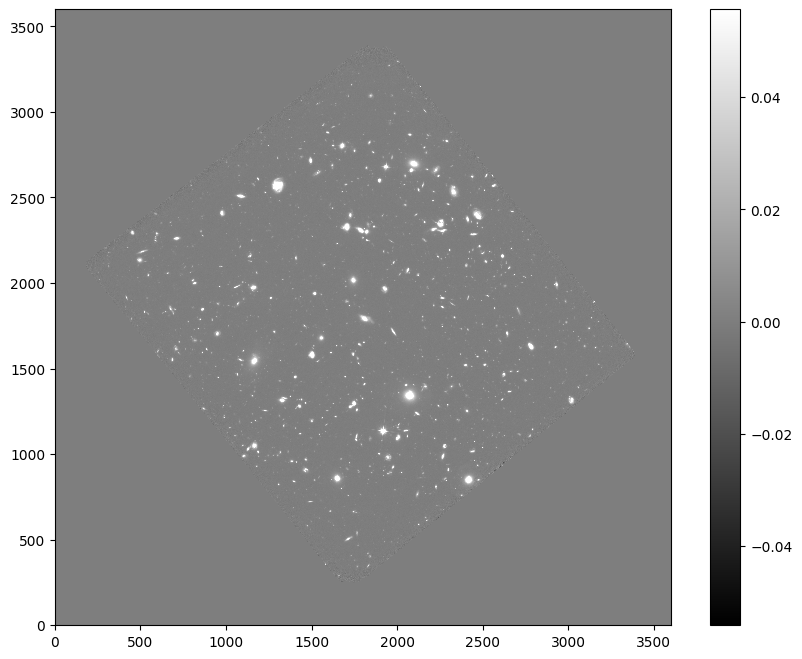

In [ ]:
data = fitsio.read('hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits')

m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

Here we measure the background of the image, and it returns it as a background object that we can do stuff with. Here we also display it. And we get a the global mean and noise of the background.

0.0
0.0005398219218477607


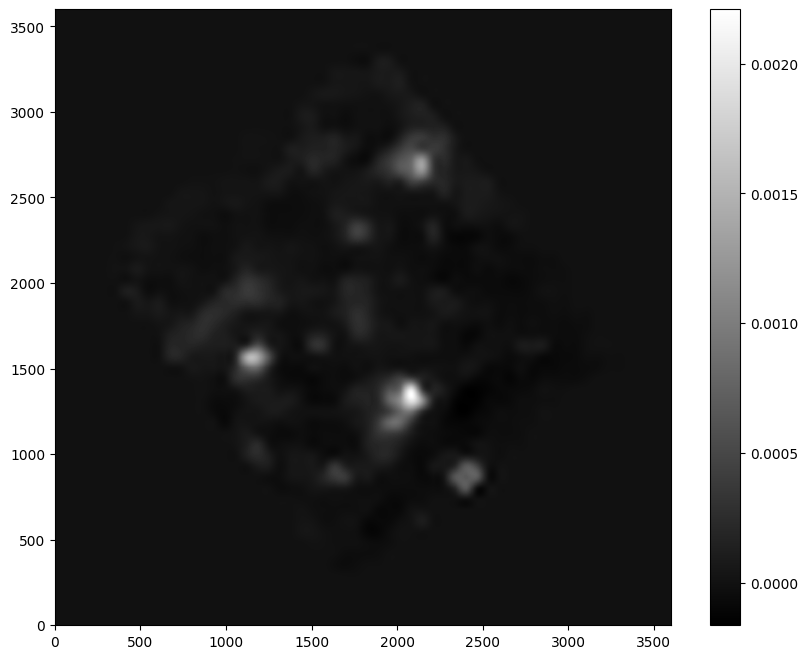

In [ ]:
bkg = sep.Background(data)

print(bkg.globalback)
print(bkg.globalrms)

bkg_image = bkg.back()

plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();



This is the background noise, and we also evaluate the noise in a 2-D array.

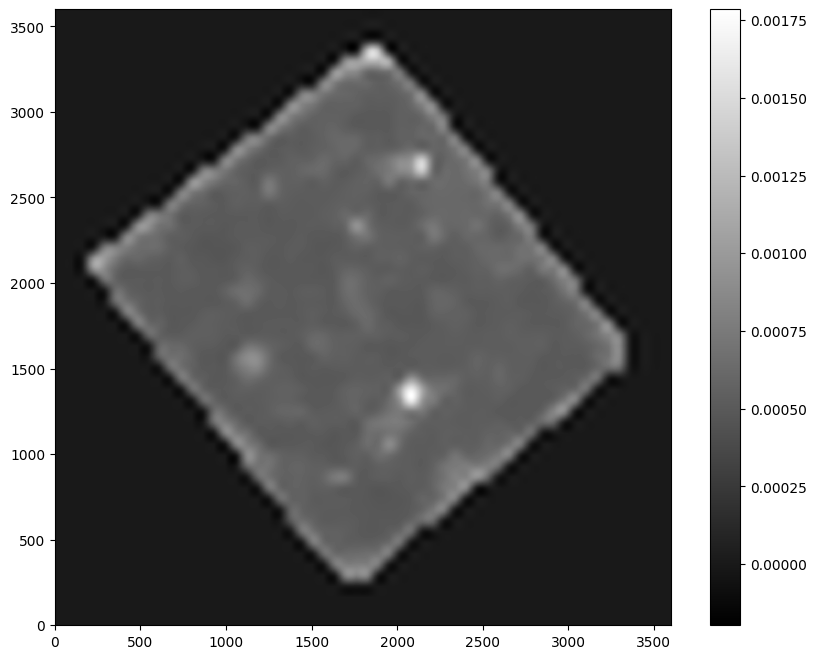

In [ ]:
bkg_rms = bkg.rms()
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

And we subtract the background from the data array.
And also find the amount of objects without the background.
I adjusted the threshold to detect less noise, and to make the image clearer.

In [ ]:

data_sub = data - bkg
objects = sep.extract(data_sub, 3.0, err=bkg.globalrms)

len(objects)

4346

Here we plot the objects, and circle them with red ellipses and circles.

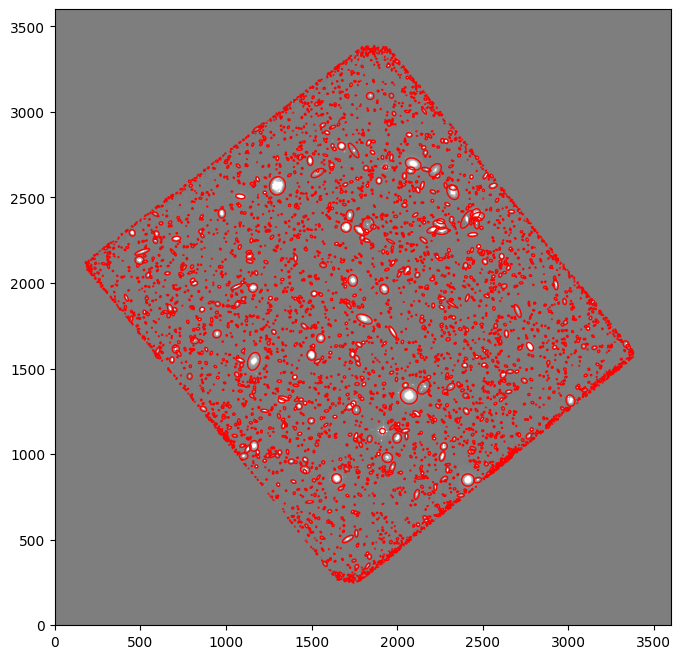

In [ ]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

Here prints the available fields which provide different information. The flux values are used for this analysis.

In [ ]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

Here we do aperture photography to measure the flux or brightness of each source.

In [ ]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.029831 +/- 0.172742
object 1: flux = 0.085622 +/- 0.292626
object 2: flux = 0.026933 +/- 0.164137
object 3: flux = 0.046099 +/- 0.214727
object 4: flux = 0.064379 +/- 0.253747
object 5: flux = 0.070986 +/- 0.266448
object 6: flux = 0.026083 +/- 0.161527
object 7: flux = 0.104682 +/- 0.323559
object 8: flux = 0.044953 +/- 0.212041
object 9: flux = 0.042711 +/- 0.206686


1) How many sources (stars) do you find in the data? Histogram their fluxes.


Using SEP, I found 4346 sources. And the histogram produced shows the distribution of the source fluxes.

Number of sources: 4346


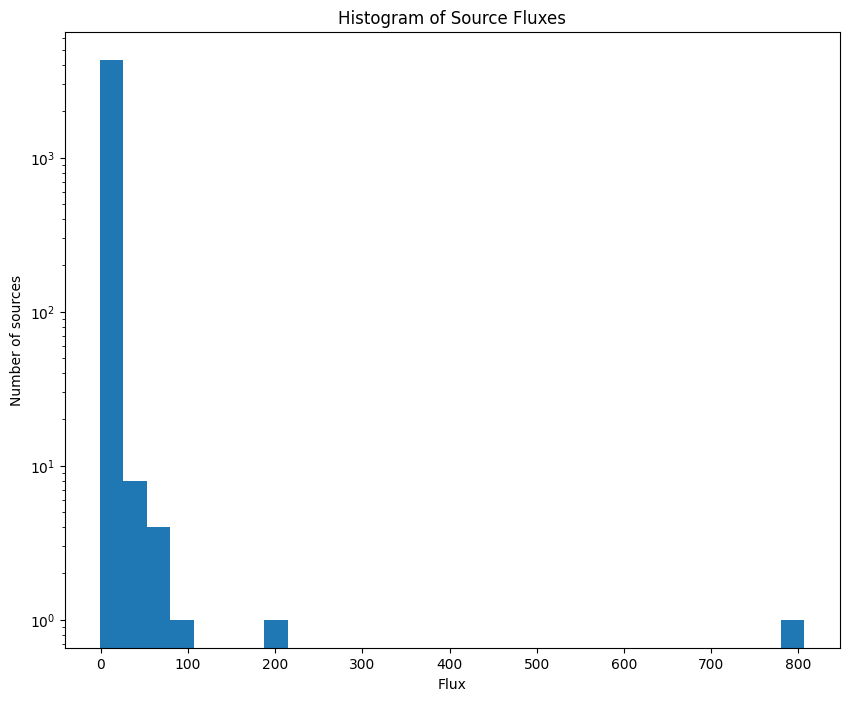

In [ ]:
print("Number of sources:", len(objects))

plt.hist(flux, bins=30, log=True)
plt.xlabel("Flux")
plt.ylabel("Number of sources")
plt.title("Histogram of Source Fluxes")
plt.show()

2) What are the mean, median, and standard deviation of the distribution of fluxes.

And the mean is about 0.705, median is about 0.074, and the standard deviation 13.02.

In [ ]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 0.7045178204640149
Median flux: 0.07376065888151061
Standard deviation: 13.022830000052


3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

The largest outlier is about 807.11 and it is about 62 standard deviations from the mean.


In [ ]:
largest_outlier = np.max(flux)
z_score = (largest_outlier - mean_flux) / std_flux

print("Largest outlier flux:", largest_outlier)
print("Standard deviations from mean:", z_score)

Largest outlier flux: 807.1093853378296
Standard deviations from mean: 61.92239839682662
